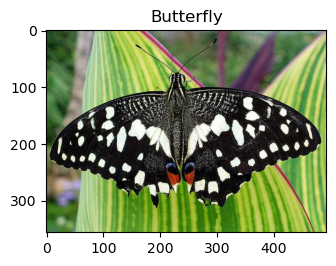

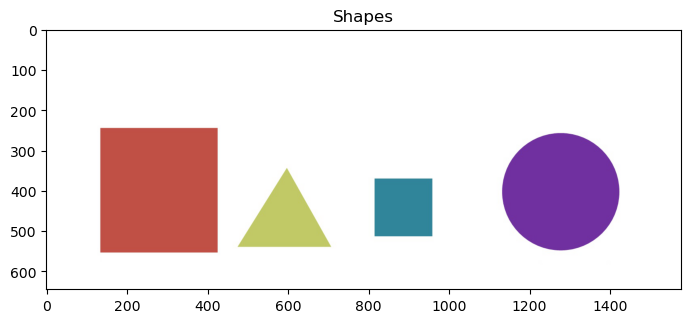

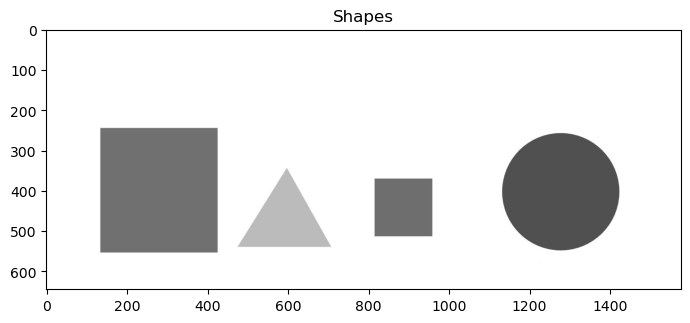

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 20):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

butterfly = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/Practice notebooks/butterfly.jpg')
imshow('Butterfly', butterfly, size=5)
shapes = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/bunchofshapes.jpg')
imshow('Shapes',shapes, 20)
shapes_gray = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/bunchofshapes.jpg',0)
imshow('Shapes',shapes_gray, 20)


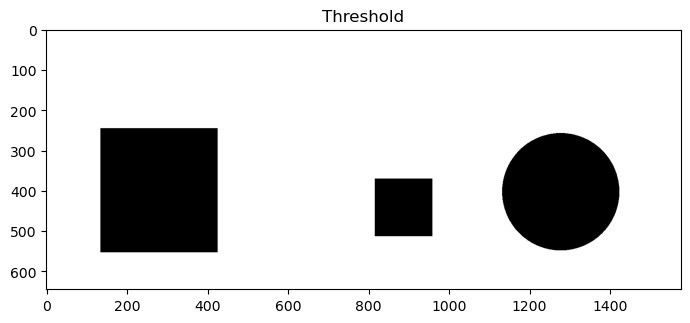

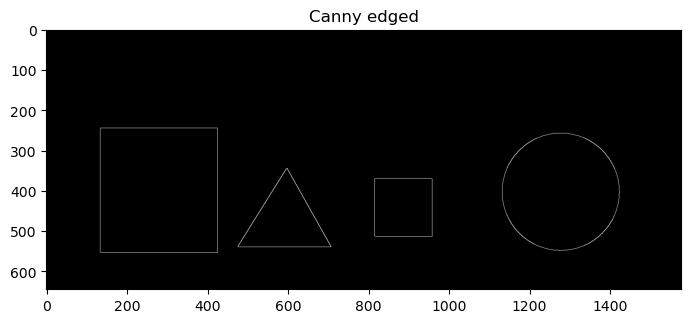

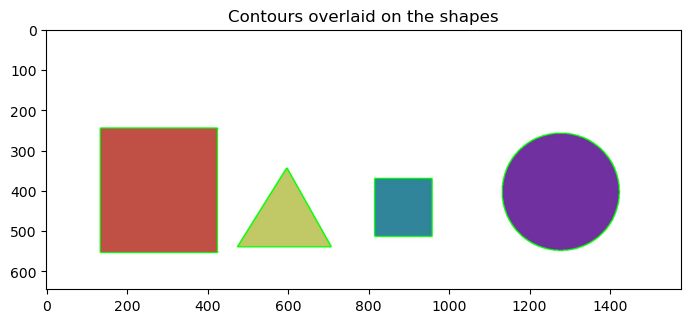

In [2]:
_ , thresh2 = cv2.threshold(shapes_gray, 122,255, cv2.THRESH_BINARY+ cv2.THRESH_OTSU)
imshow('Threshold', thresh2, 20) # we can't use threshold method here, coz if we use it pixels those are greater than 127 turn into 255 or pure white, it means that that some elements might be eliminated, so, we can also use canny method to find only edges!

edged = cv2.Canny(shapes_gray, 50, 255)
imshow('Canny edged', edged, 20)

contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(shapes, contours, -1, (0, 255, 0), 2)
imshow('Contours overlaid on the shapes', shapes, 20)

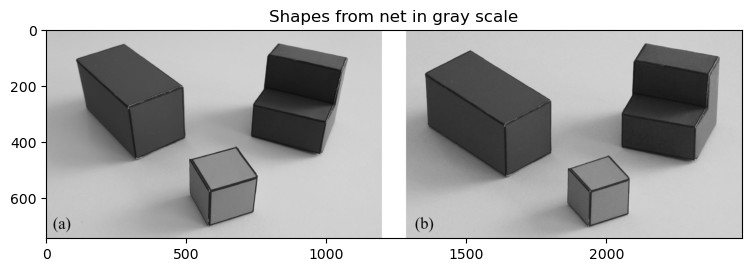

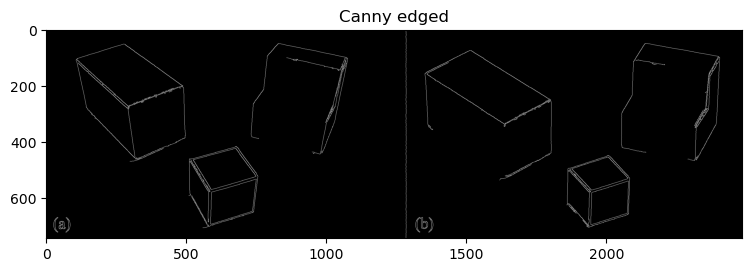

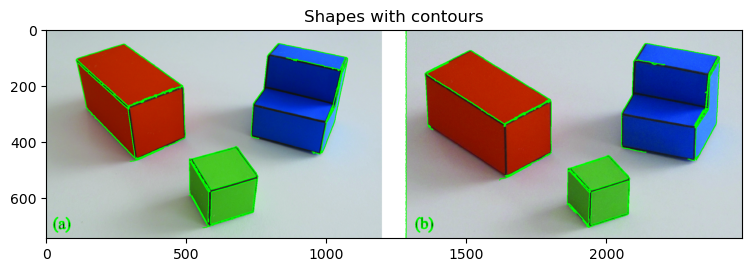

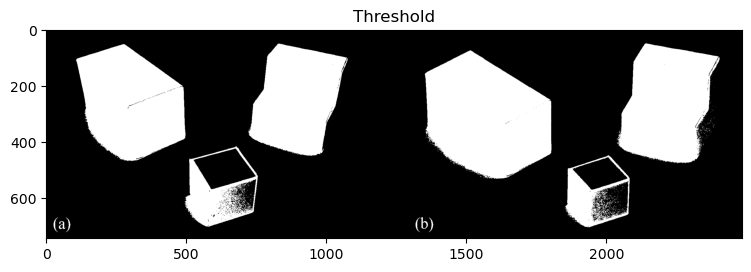

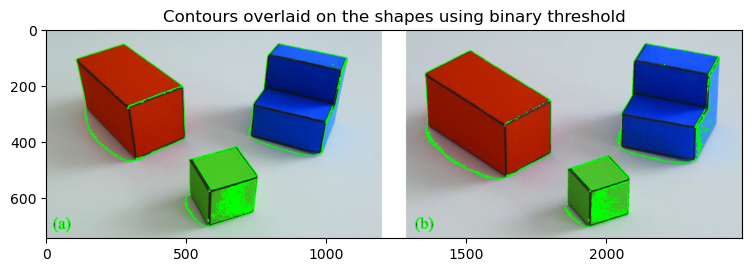

In [3]:
shapes_from_net = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/shapes from net.png')
shapes_from_net_gray = cv2.cvtColor(shapes_from_net, cv2.COLOR_BGR2GRAY)
imshow('Shapes from net in gray scale', shapes_from_net_gray, 30)
canny_edged = cv2.Canny(shapes_from_net_gray, 50, 255)
imshow('Canny edged', canny_edged, 30)

contours, hiercharchy = cv2.findContours(canny_edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(shapes_from_net, contours, -1, (0,255,0), 2)
imshow('Shapes with contours', shapes_from_net, 30) # here Canny algorithm is not successfull, and next try let's use threshold for finding edges


# Let's use binary thresholds for this image

shapes_from_net2 = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/shapes from net.png')
shapes_from_net_gray2 = cv2.cvtColor(shapes_from_net2, cv2.COLOR_BGR2GRAY)

_ , thresh2 = cv2.threshold(shapes_from_net_gray2, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(thresh2, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
imshow('Threshold', thresh2, 30)
cv2.drawContours(shapes_from_net2, contours, -1, (0,255,0),2)
imshow('Contours overlaid on the shapes using binary threshold', shapes_from_net2, 30) # Using these image Canny algorithm is better coz output or result is better than the second one!


### **CounterArea**


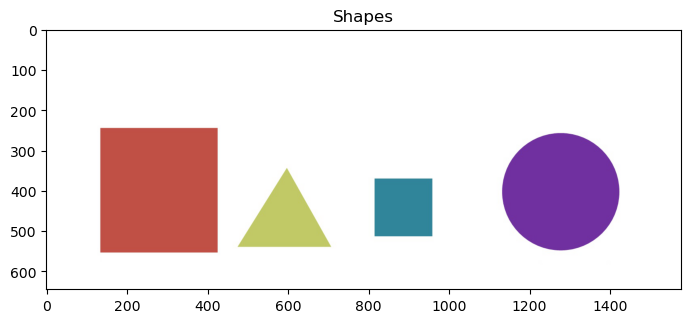

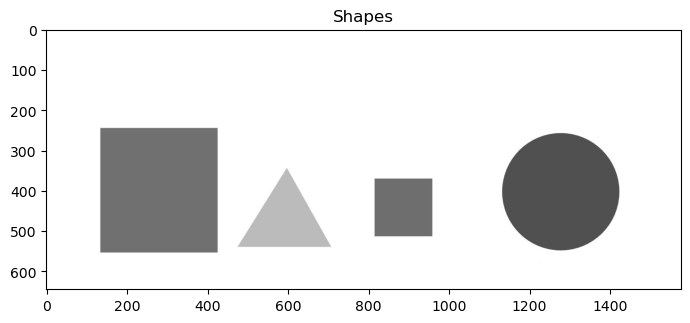

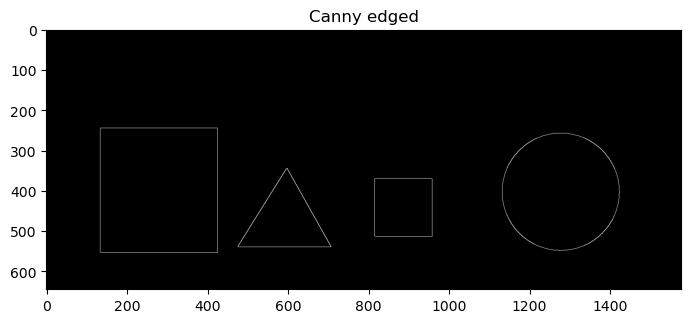

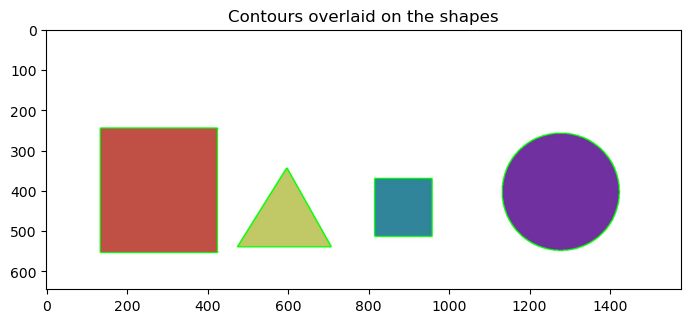

Contour areas before sorting...
Image: Shapes from net
[20586.5, 22901.5, 66574.5, 89918.0]
Contour areas after sorting...
Image: Shapes from net
[89918.0, 66574.5, 22901.5, 20586.5]


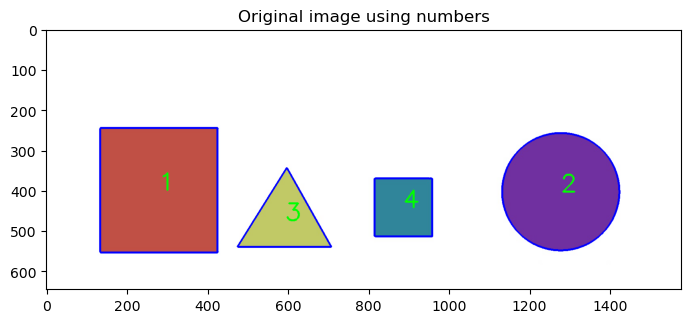

In [4]:
shapes = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/bunchofshapes.jpg')
imshow('Shapes',shapes, 20)
shapes_gray = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/bunchofshapes.jpg',0)
imshow('Shapes',shapes_gray, 20)

edged = cv2.Canny(shapes_gray, 50, 255)
imshow('Canny edged', edged, 20)

contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(shapes, contours, -1, (0, 255, 0), 2)
imshow('Contours overlaid on the shapes', shapes, 20)

def get_contour_areas(title, contours):
    all_areas = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        all_areas.append(area)
    print('Image:',title)
    return all_areas


print('Contour areas before sorting...')
print(get_contour_areas('Shapes from net', contours))

sorted_contours = sorted(contours, key = cv2.contourArea, reverse=True)

print('Contour areas after sorting...')
print(get_contour_areas('Shapes from net', sorted_contours))

for (i,c) in enumerate(sorted_contours):
    M = cv2.moments(c)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    cv2.putText(shapes, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
    cv2.drawContours(shapes, [c], -1, (255,0,0), 3)

imshow('Original image using numbers', shapes, 20)

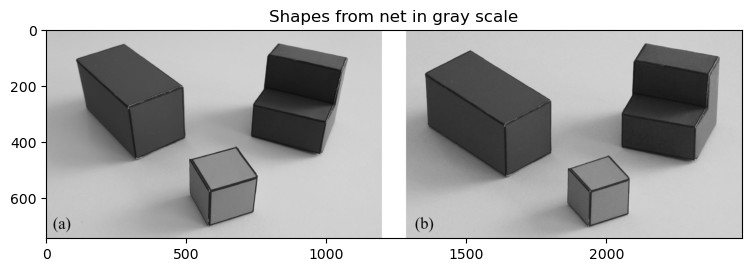

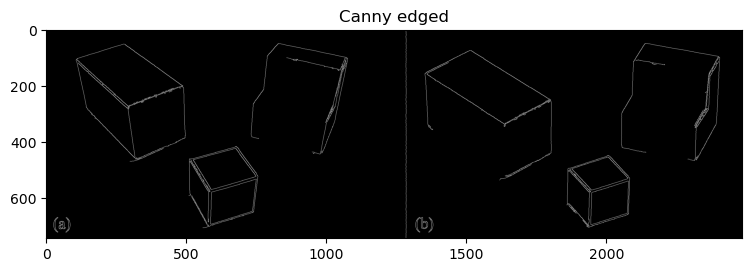

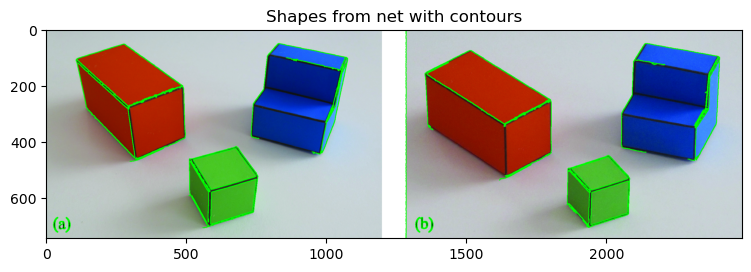

In [5]:
shapes_from_net = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/shapes from net.png')
shapes_from_net_gray = cv2.cvtColor(shapes_from_net, cv2.COLOR_BGR2GRAY)
imshow('Shapes from net in gray scale', shapes_from_net_gray, 30)
canny_edged = cv2.Canny(shapes_from_net_gray, 50, 255)
imshow('Canny edged', canny_edged, 30)

contours, hiercharchy = cv2.findContours(canny_edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(shapes_from_net, contours, -1, (0,255,0), 2)
imshow('Shapes from net with contours', shapes_from_net, 30)

In [6]:
shapes_from_net = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/shapes from net.png')
shapes = cv2.imread('')

[ WARN:0@3.786] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity


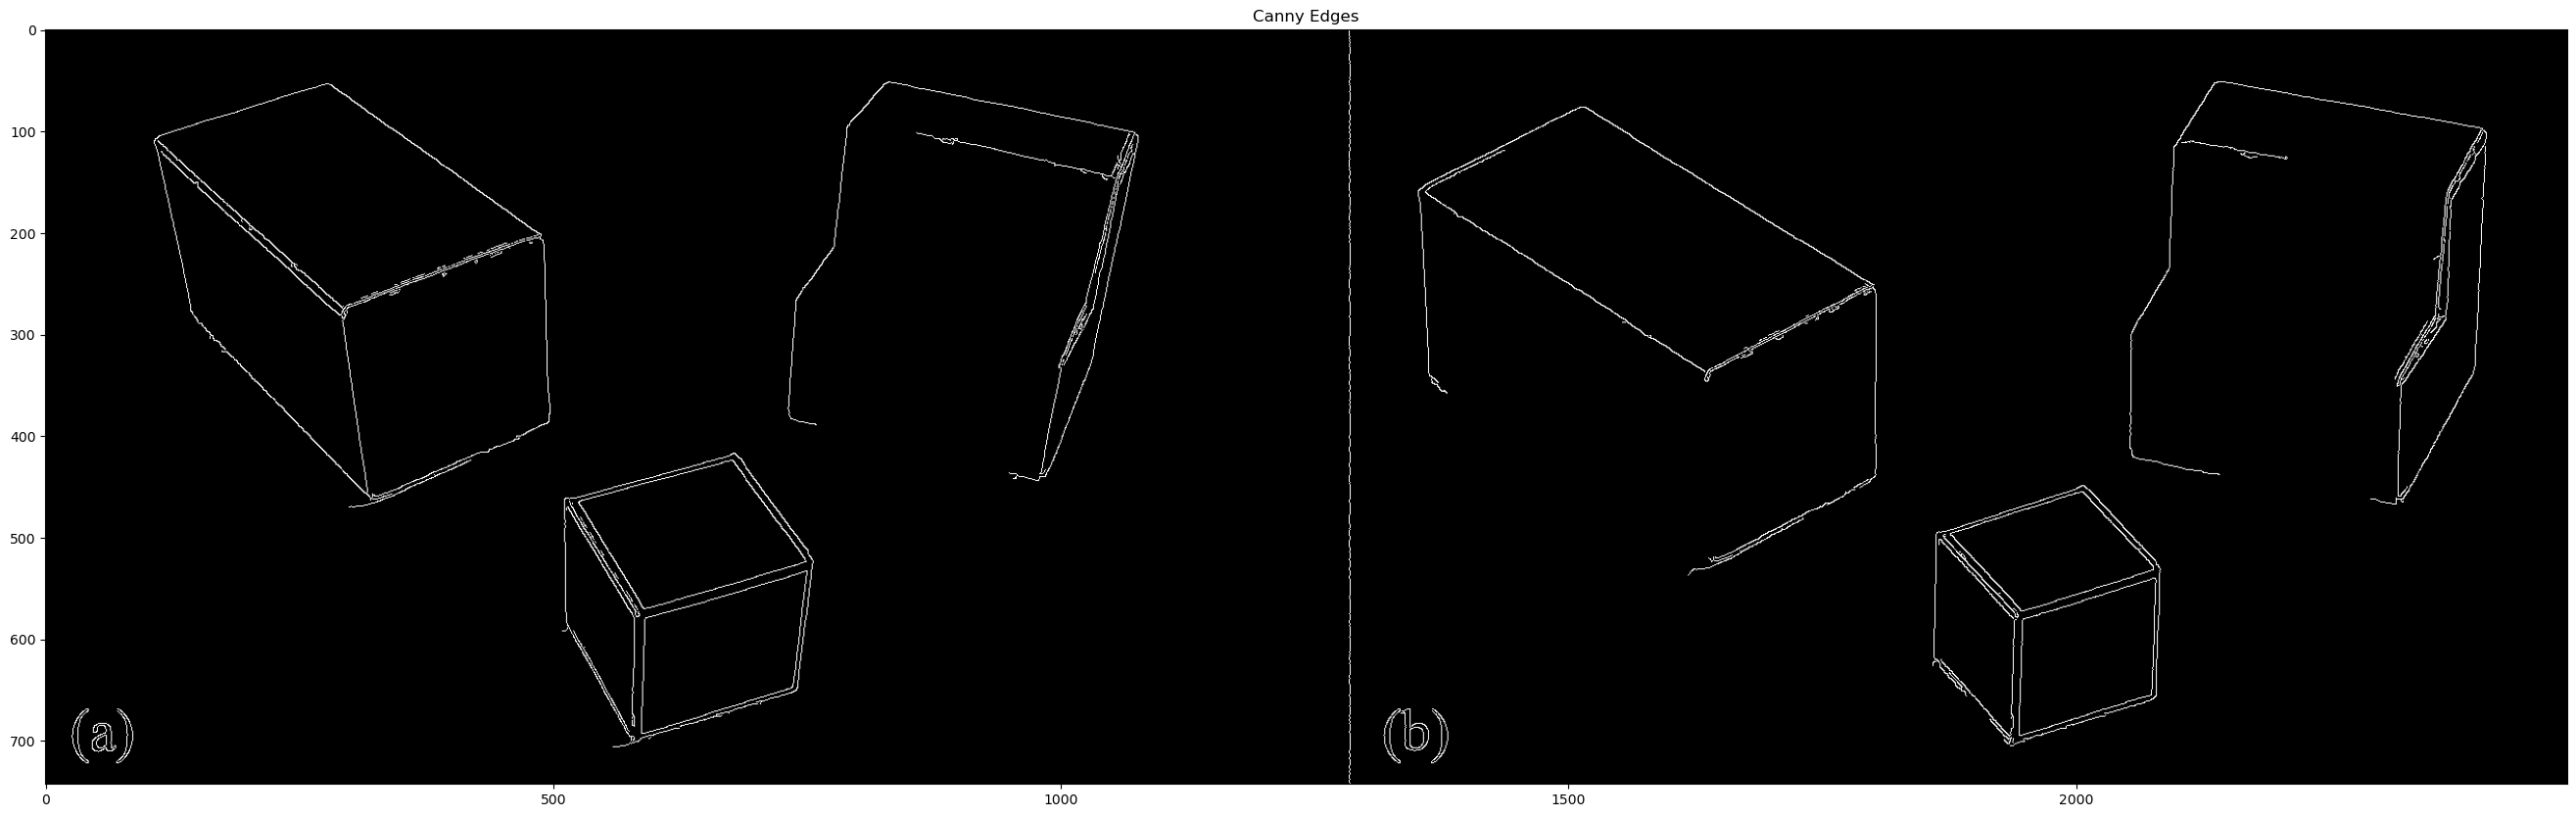

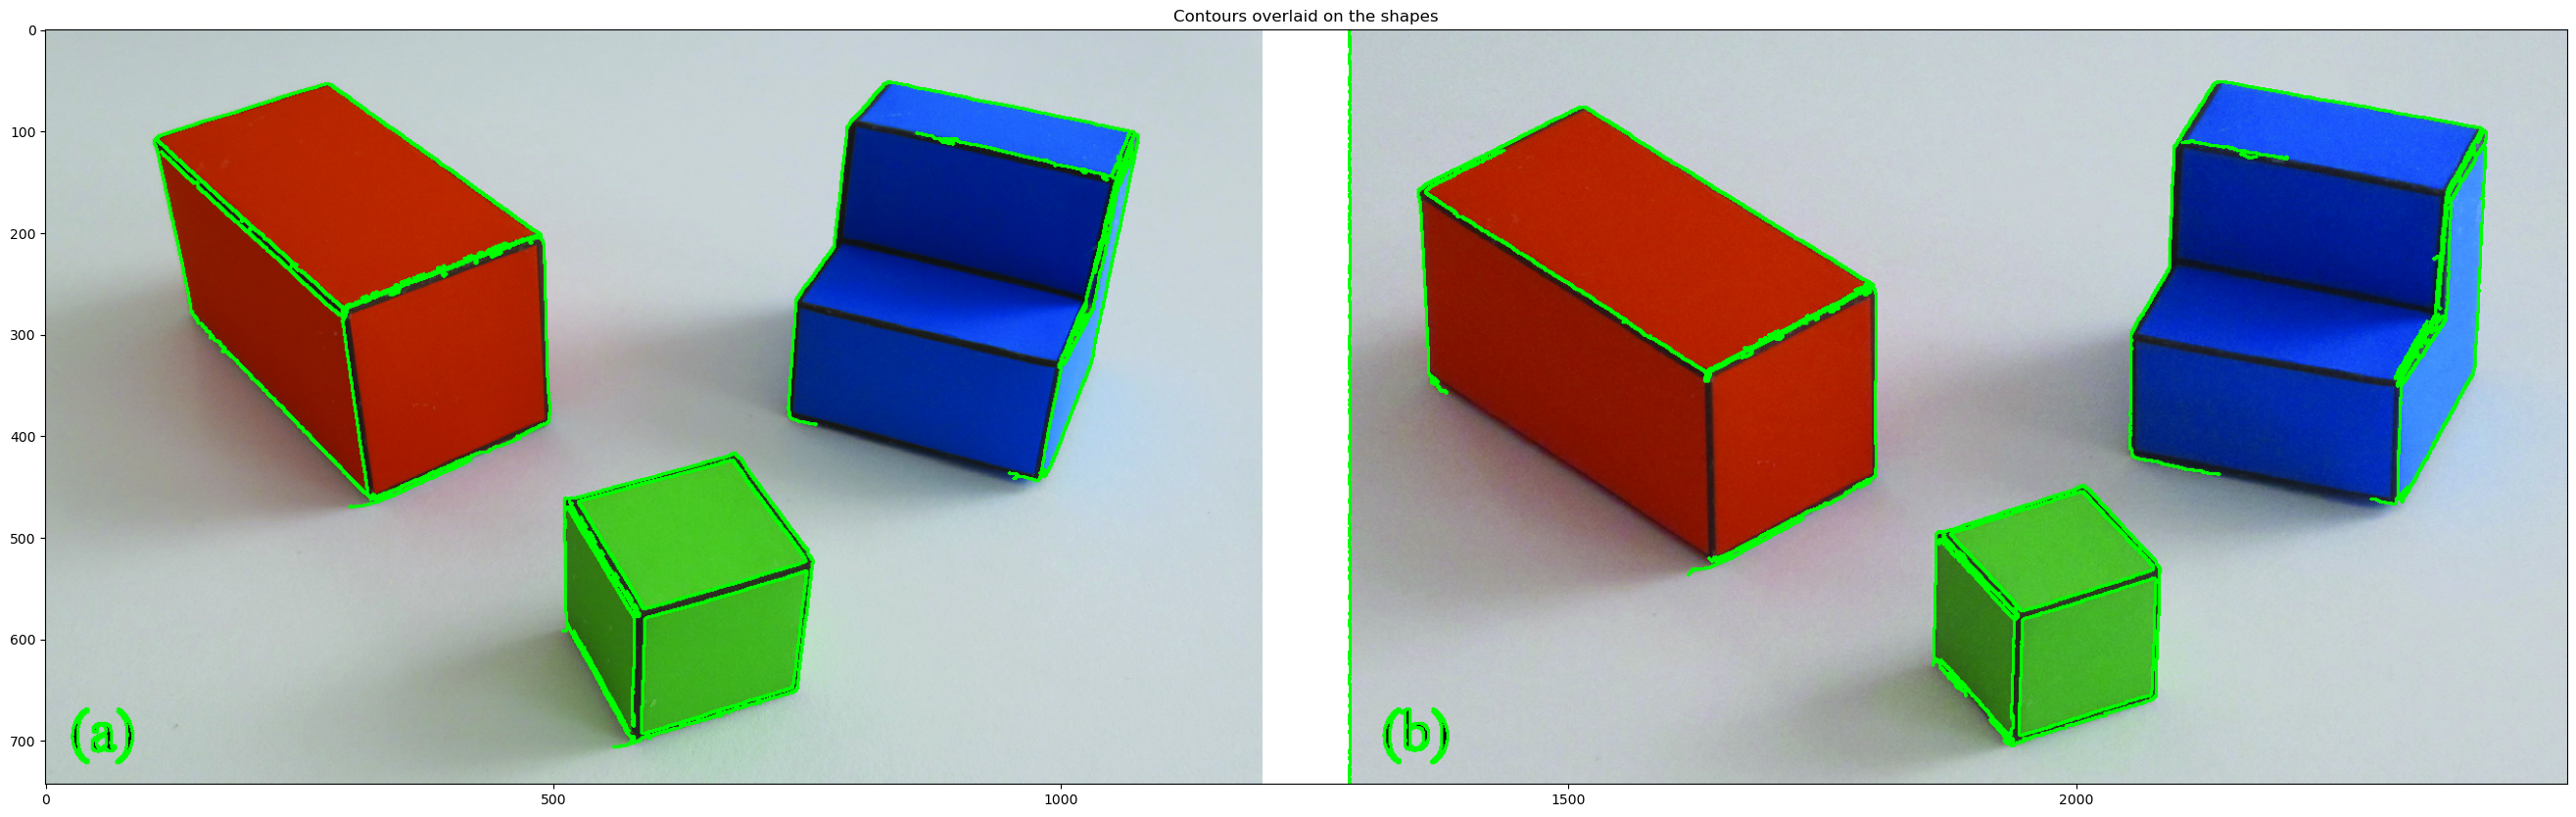

Contour areas before sorting...
[4.0, 5.5, 0.0, 0.0, 87.5, 229.0, 2.5, 4.0, 258.0, 383.5, 22.5, 17.0, 7.0, 9.0, 209.0, 210.0, 20.5, 254.0, 230.0, 20.5, 231.0, 7.0, 124.0, 23.0, 22.0, 58.0, 1.0, 14892.0, 14904.0, 4.0, 17225.0, 17234.0, 2.0, 7.0, 0.0, 59.5, 81.0, 4.0, 36.0, 0.0, 64.0, 0.0, 64.5, 12970.5, 13115.0, 53.5, 112.5, 5.0, 19084.5, 19226.5, 26.0, 339.0, 28.0, 16.5, 31.0, 25.0, 9.0, 9.0, 0.0, 14.0, 0.5, 32.0, 7.0, 22.0, 4.0, 9.0, 6.0, 4.0, 6.0, 9.0, 6.0, 19.0, 4.0, 0.0, 2.5, 9.0, 9.0, 4.0, 4.0, 4.0, 22.0, 4.0, 7.5, 4.0, 4.0, 2.0, 7.0, 4.0, 2.0, 2.0, 3.5, 34.0, 4.0, 19.0, 16.0, 14.0, 2.0, 19.0, 17.0, 14.0, 9.0, 4.0, 4.0, 4.0, 18.0, 2.0, 14.0, 6.0, 6.0, 4.0, 4.0, 6.0, 4.0, 6.0, 4.0, 0.0, 4.0, 362.0, 6.0, 4.0, 6.0, 6.0, 0.0, 6.0, 6.0, 4.0, 7.0, 23.0, 11.0, 0.0, 0.5, 4.0, 4.5, 16.0, 6.0, 6.0, 6.0, 6.0, 0.0, 11.0, 0.5, 11.0, 4.0, 19.0, 6.0, 0.0, 0.0, 1.0, 1.0, 222.0, 0.0, 124.5, 0.0, 0.0, 0.0, 4.0, 4.0, 0.0, 4.0, 2.0, 13.0, 6.0, 30.5, 5.5, 10.0, 2.0, 2.0, 192.5, 31.0, 1.5, 13.5, 719.5,

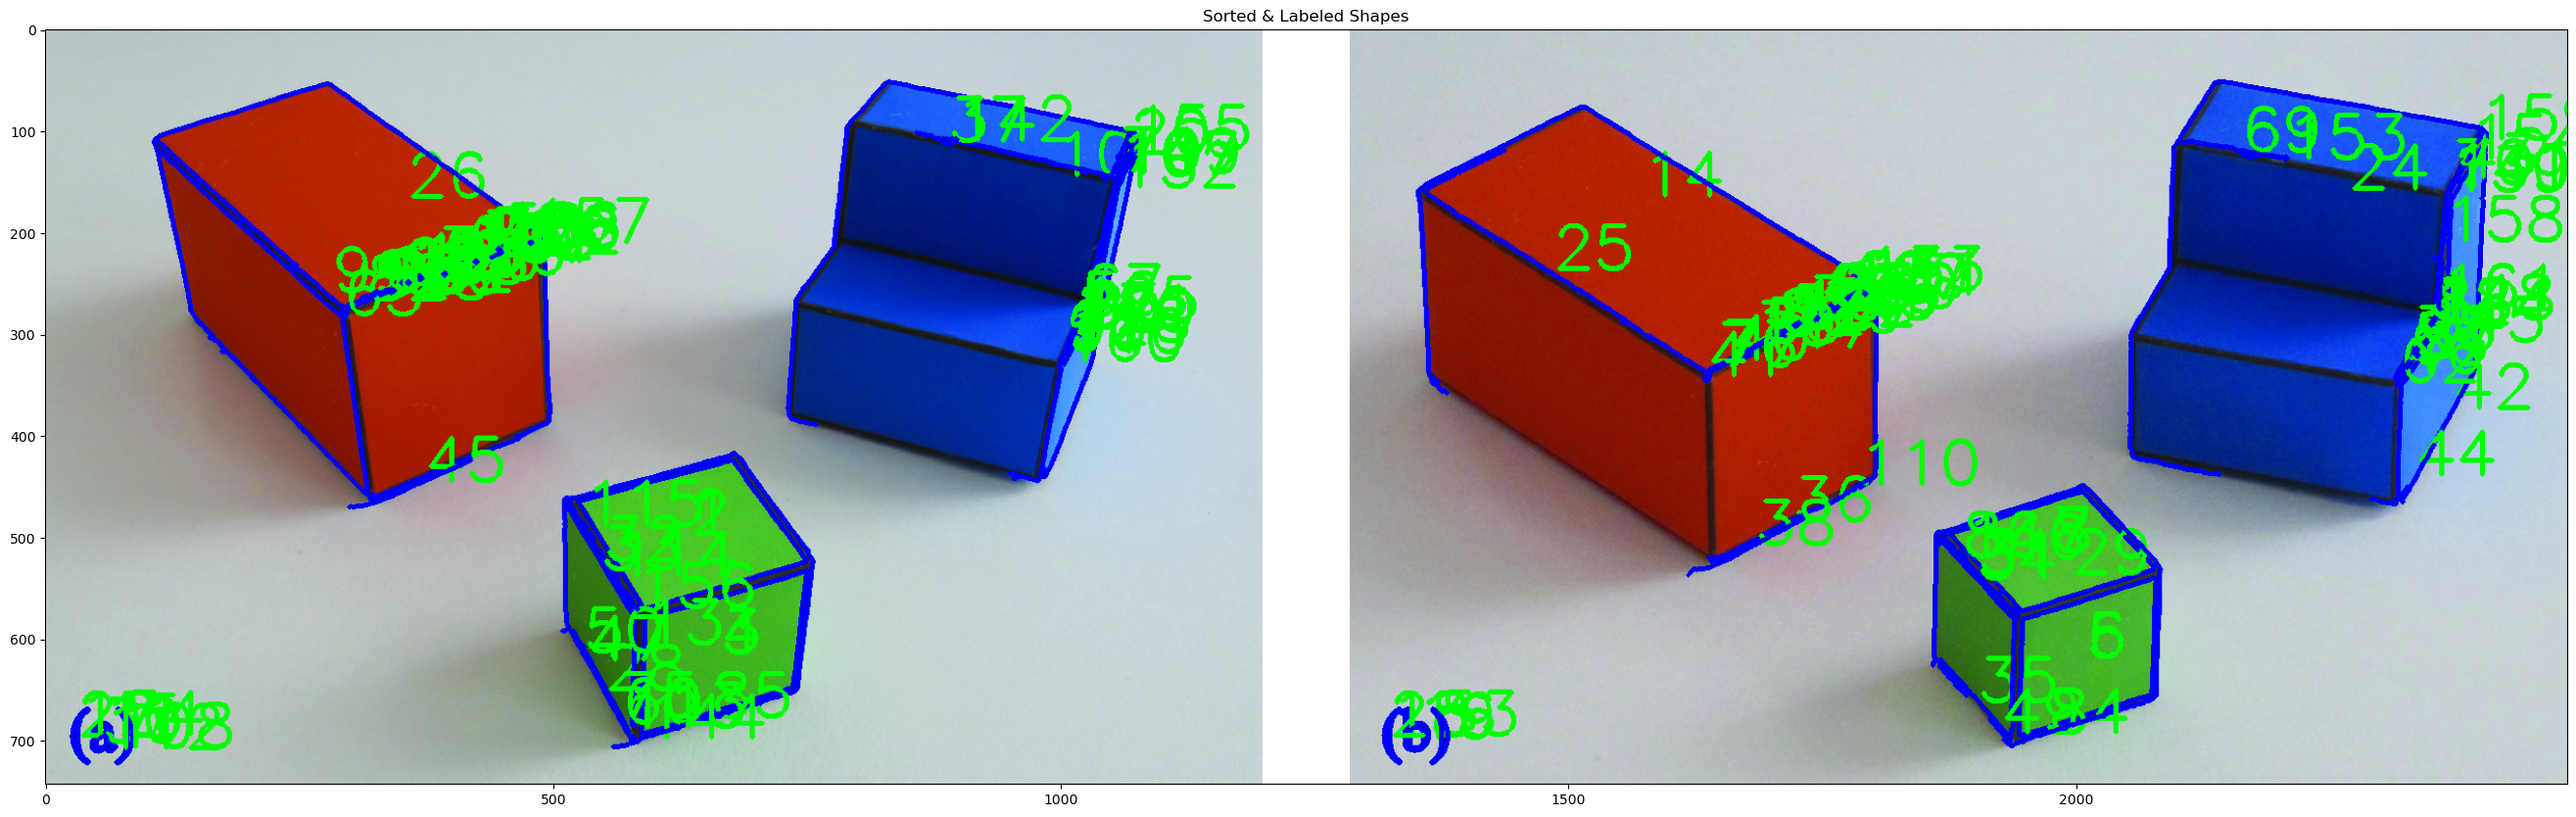

In [7]:
from putting_based_on_area import PuttingBasedOnArea

processor = PuttingBasedOnArea(shapes_from_net)
processor.finding_contours_using_canny()
processor.get_contour_areas()
processor.sort_and_label()

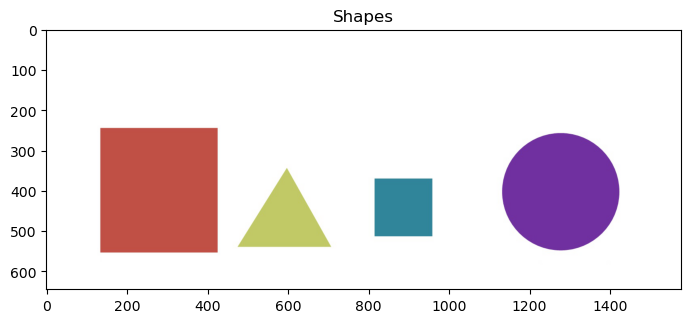

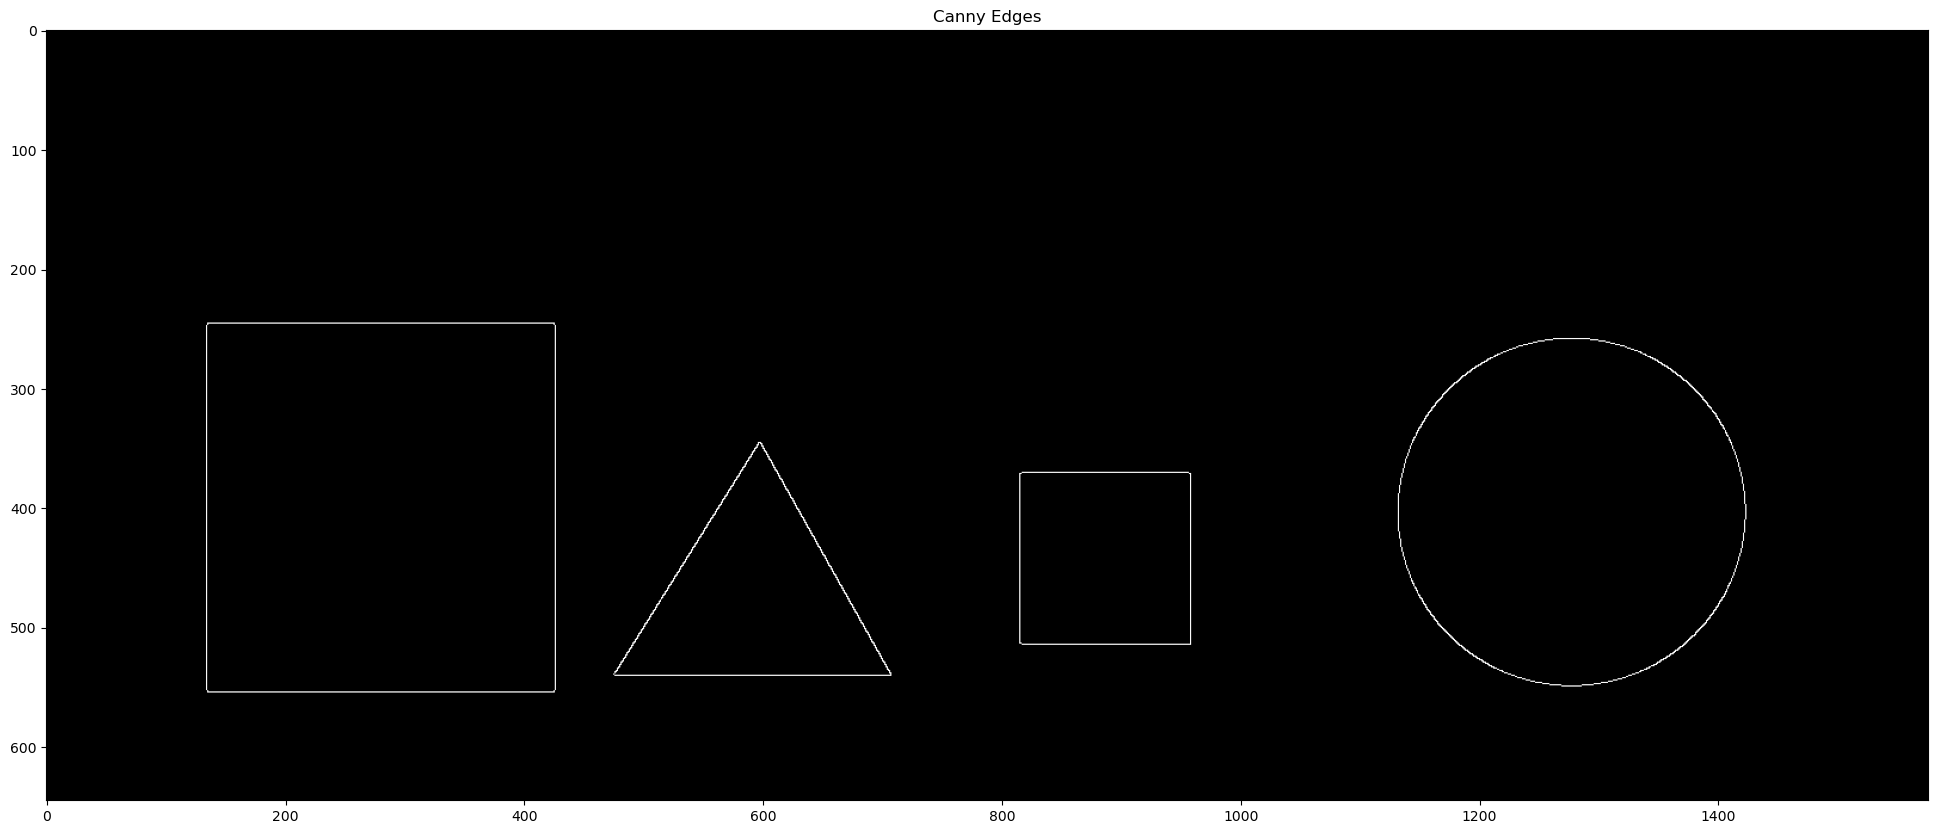

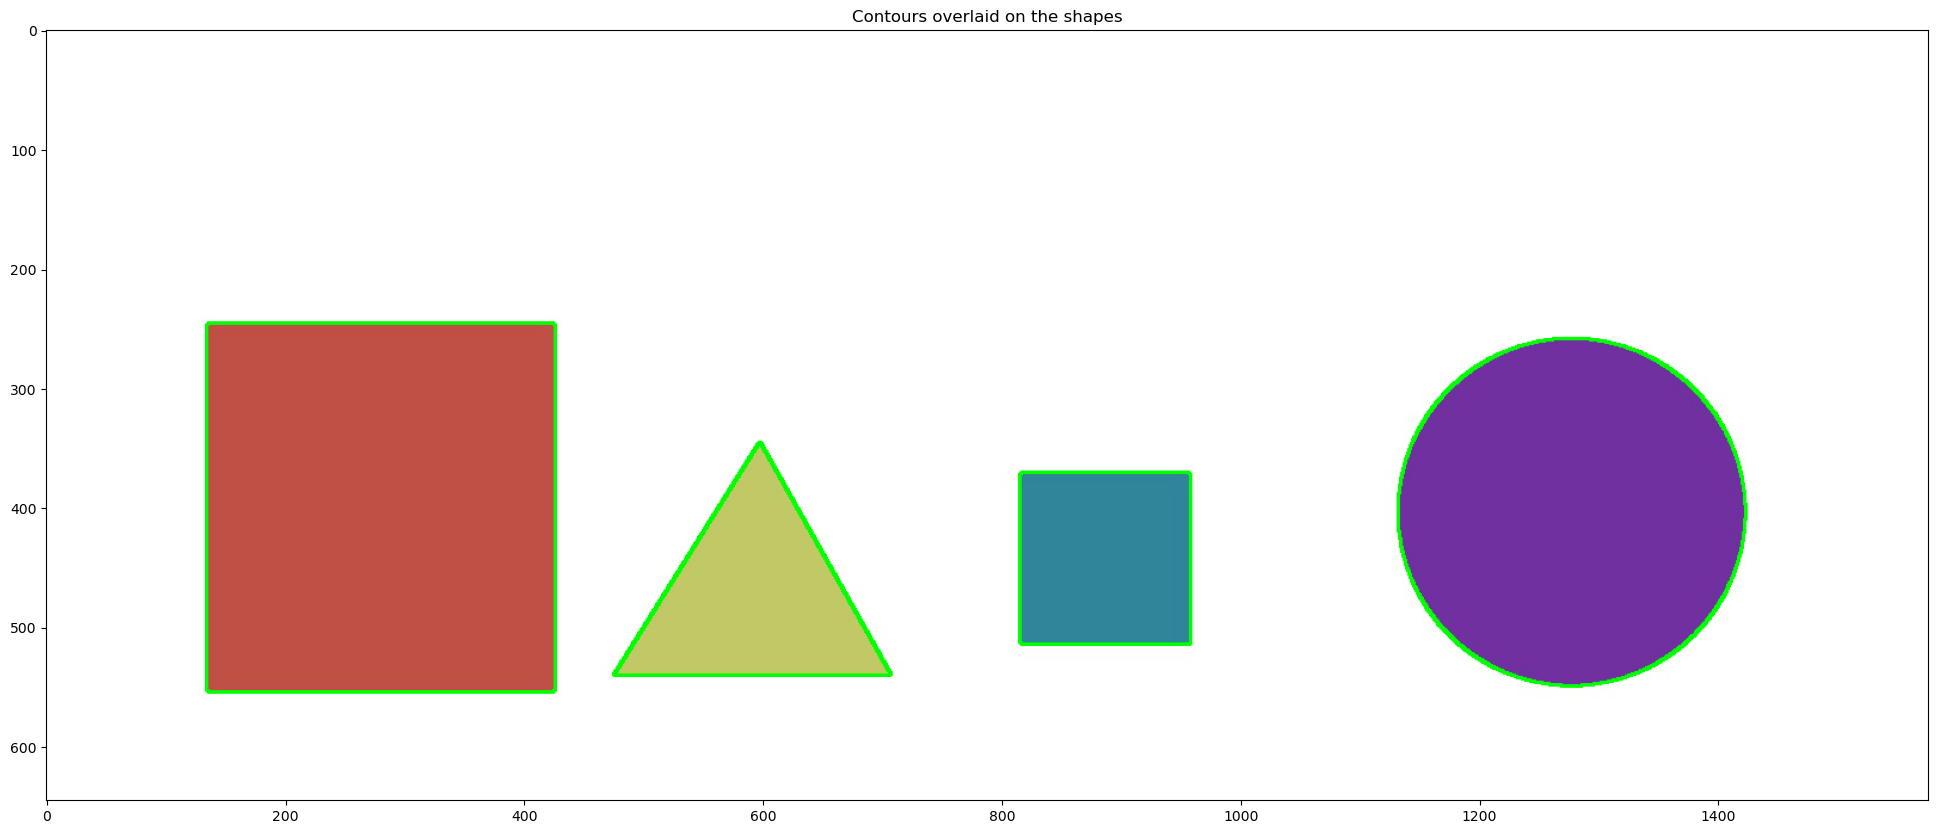

Contour areas before sorting...
[20585.5, 20587.5, 22671.0, 22900.5, 66350.5, 66581.5, 90220.0, 90222.0]
Contour areas after sorting...


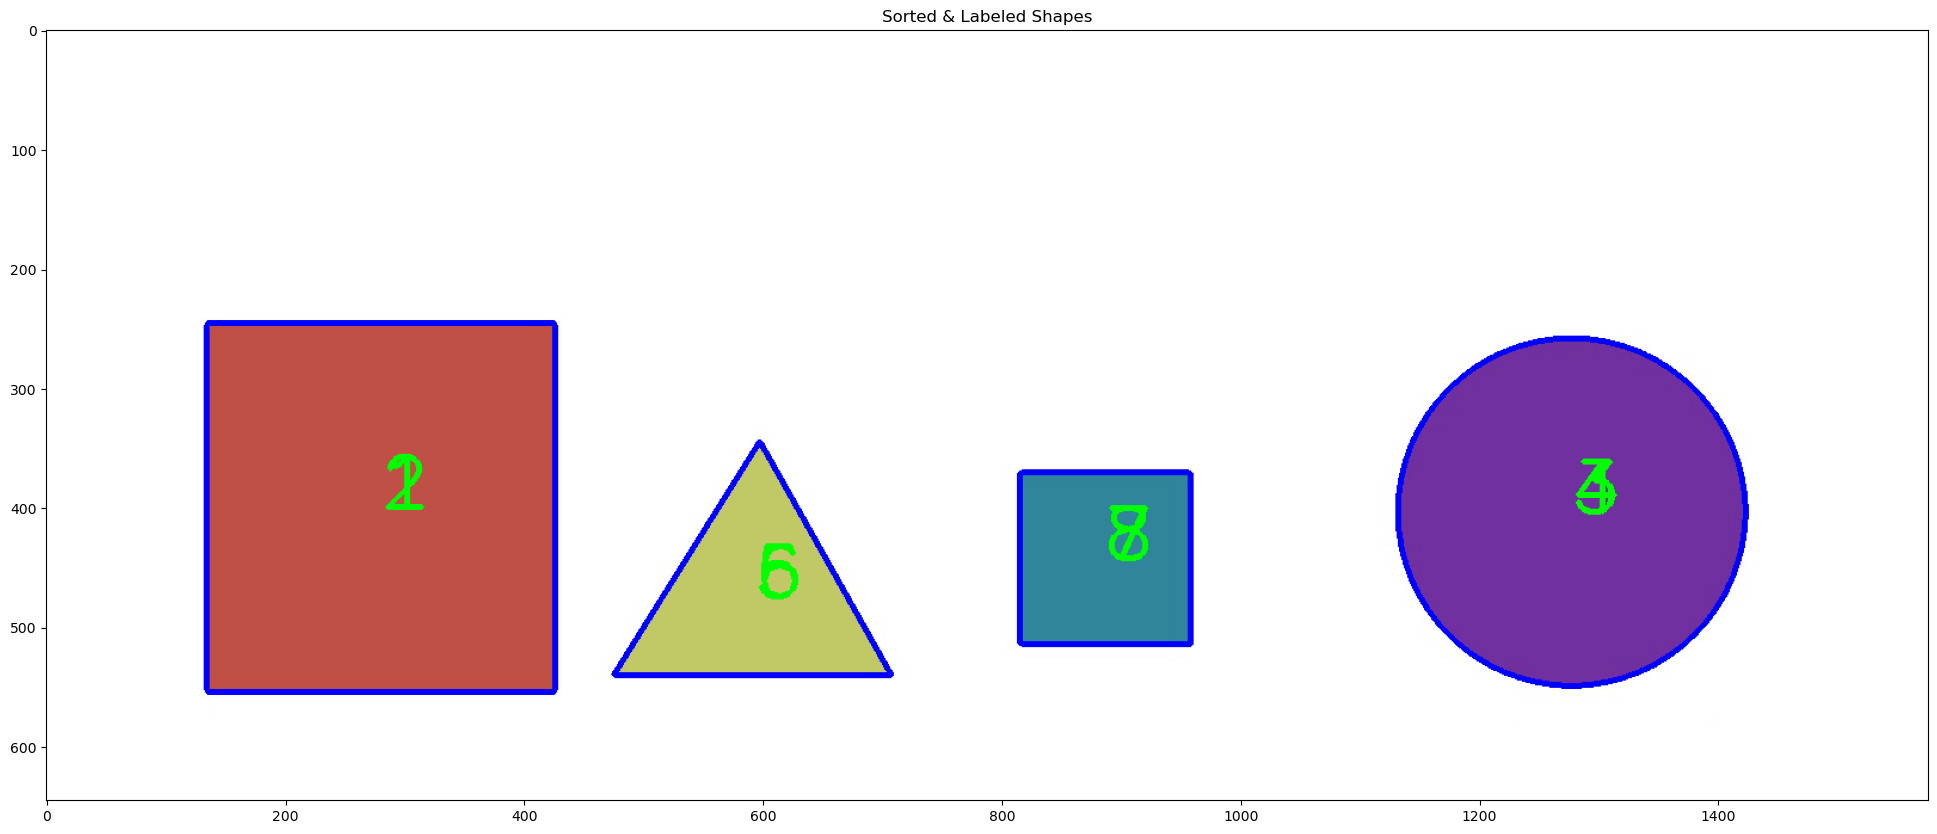

In [8]:
shapes = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/bunchofshapes.jpg')
imshow('Shapes', shapes)
shapes_processor = PuttingBasedOnArea(shapes)
shapes_processor.finding_contours_using_canny()
shapes_processor.sort_and_label()

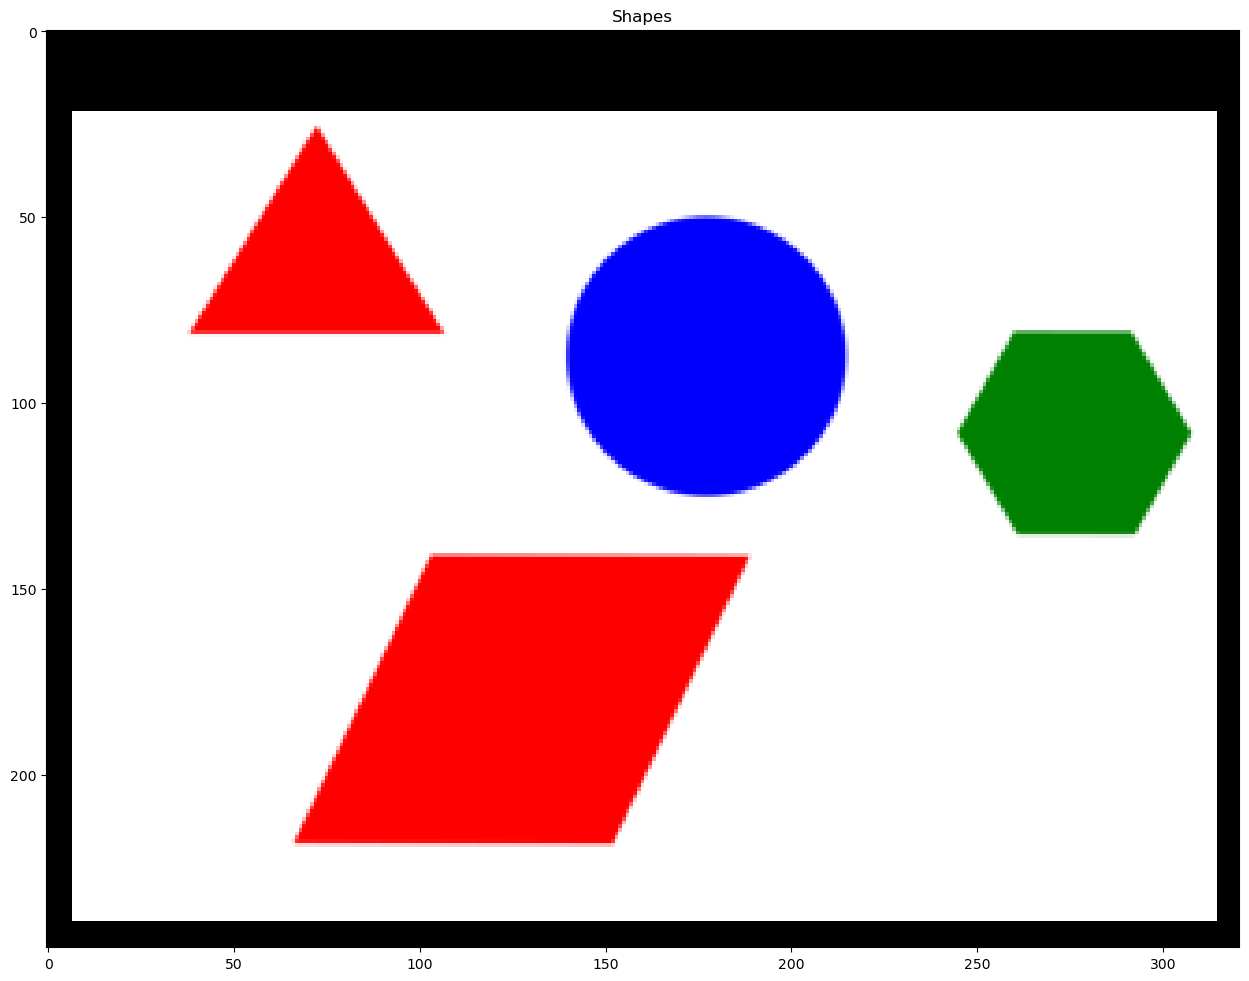

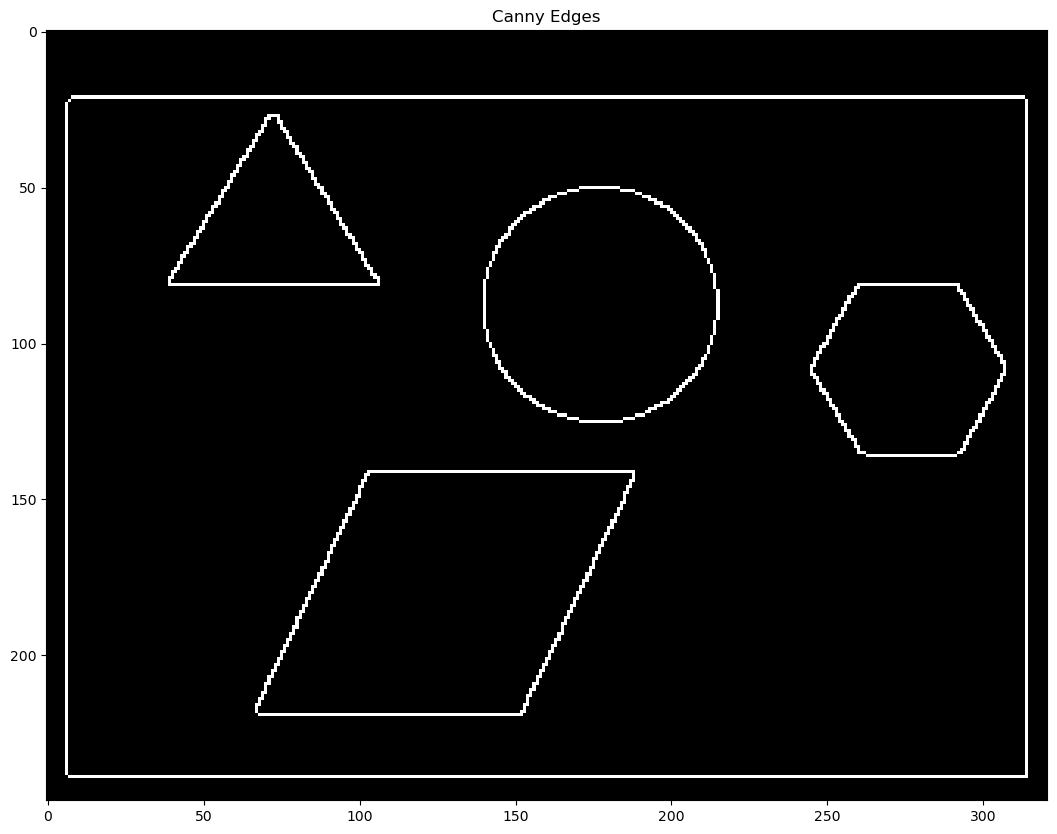

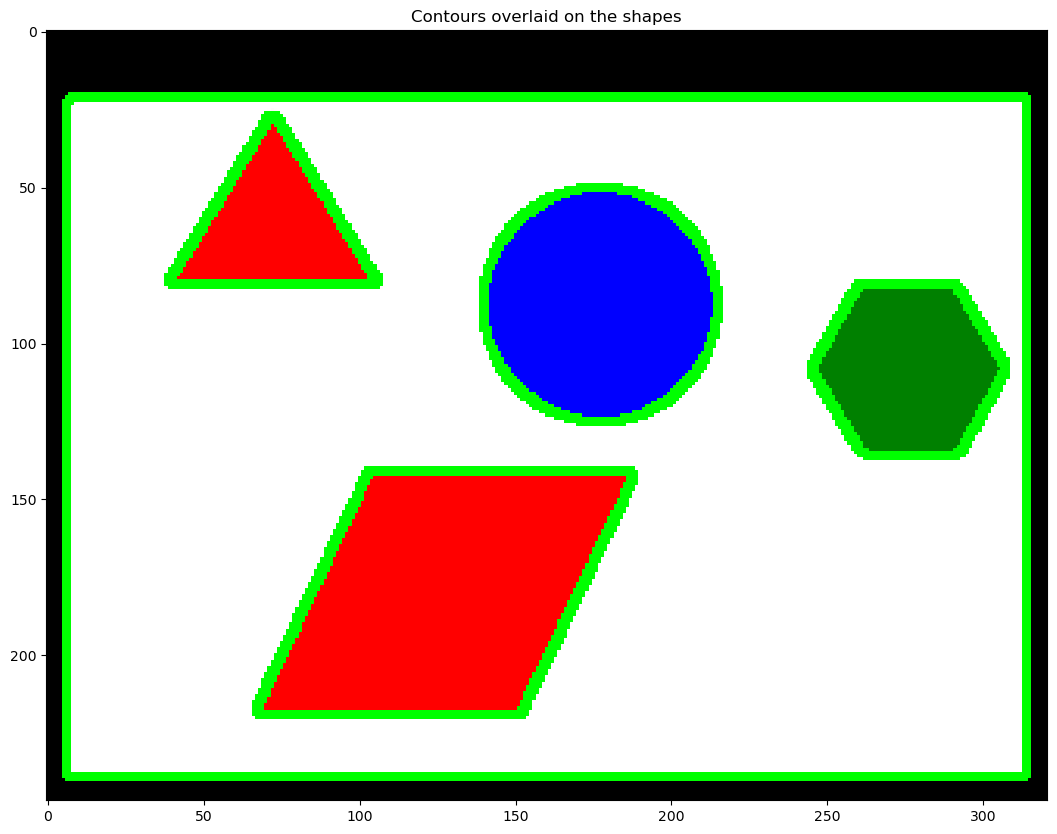

Contour areas before sorting...
[6663.0, 6736.5, 2560.5, 2621.5, 4409.0, 4471.0, 1858.0, 1924.0, 67140.5, 67141.0]
Contour areas after sorting...


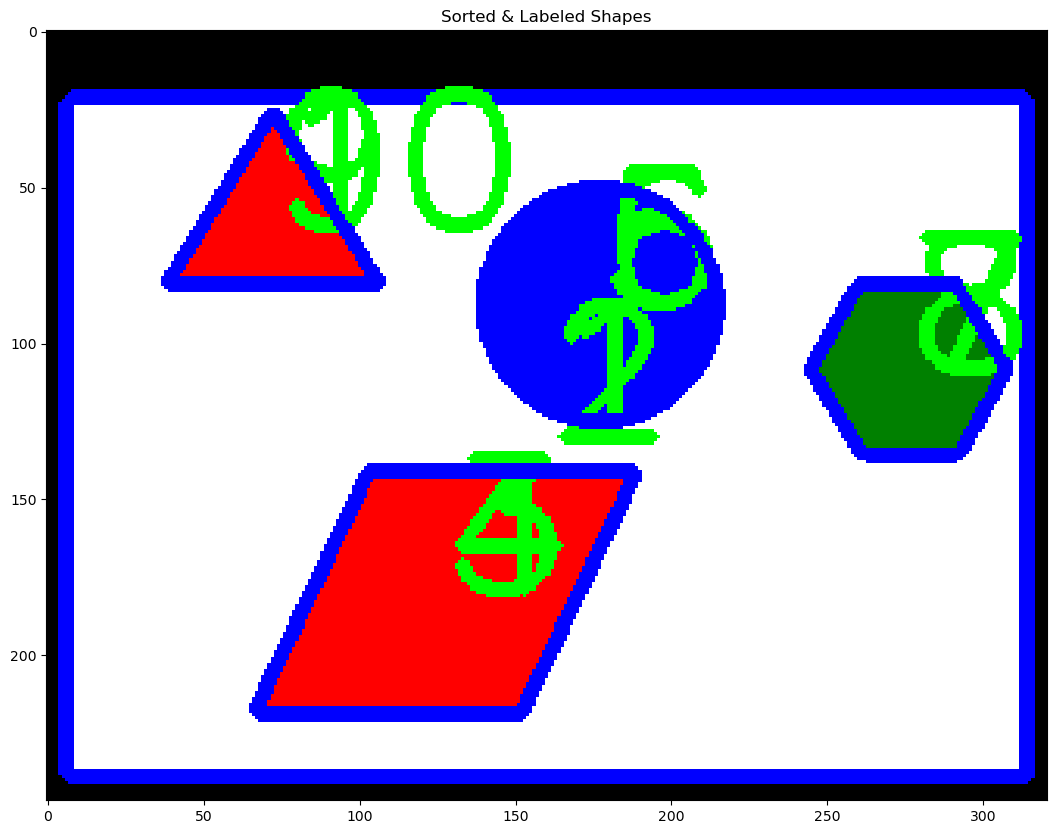

In [9]:
shapes2 = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/images_from_net2.png')
shapes2_grey = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/images_from_net2.png', 0)
imshow('Shapes', shapes2)

from putting_based_on_area import PuttingBasedOnArea

processor = PuttingBasedOnArea(shapes2)

shapes_processor = PuttingBasedOnArea(shapes2)
shapes_processor.finding_contours_using_canny()
shapes_processor.sort_and_label()

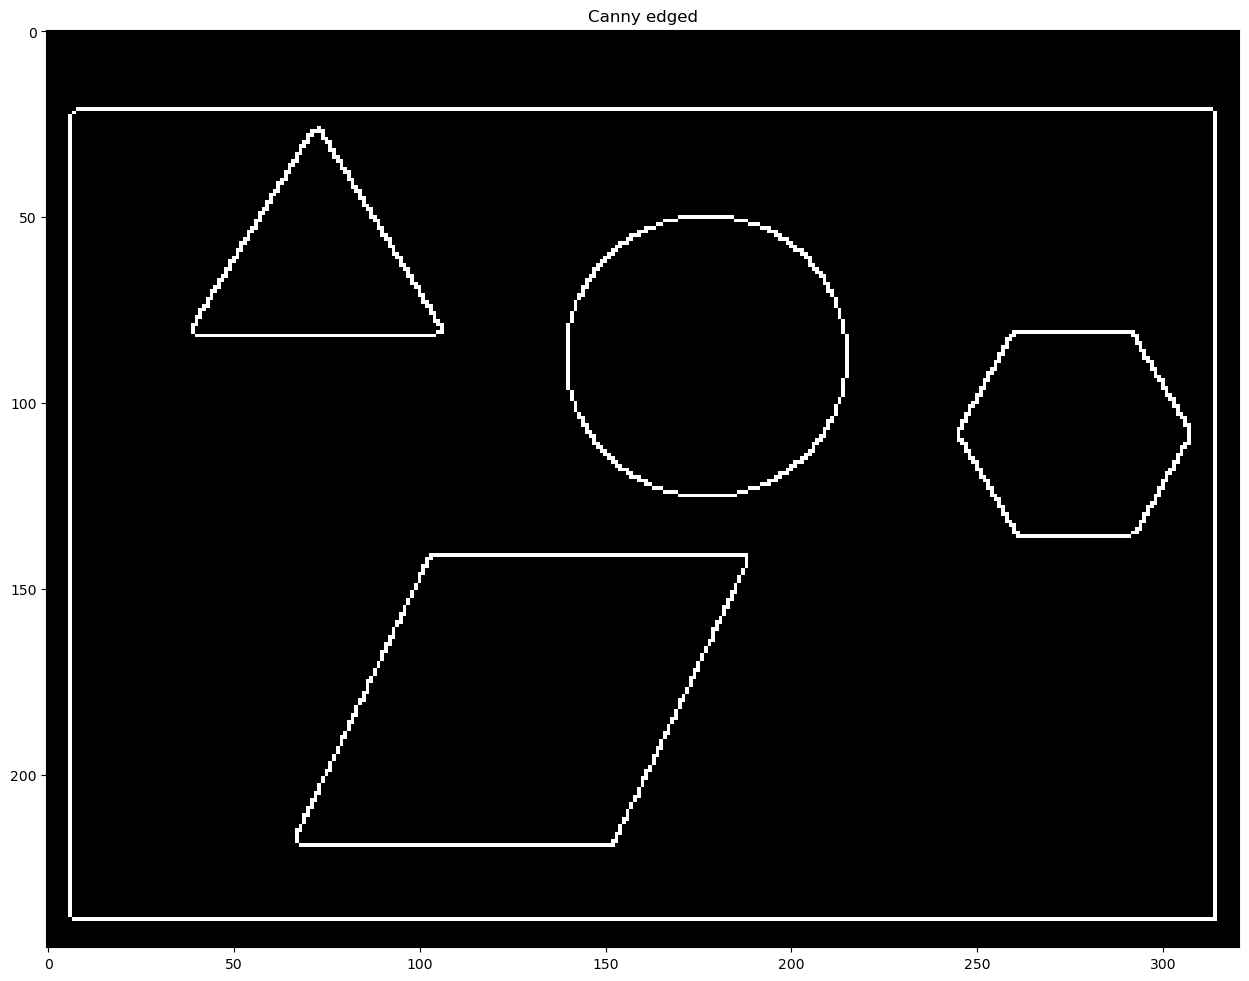

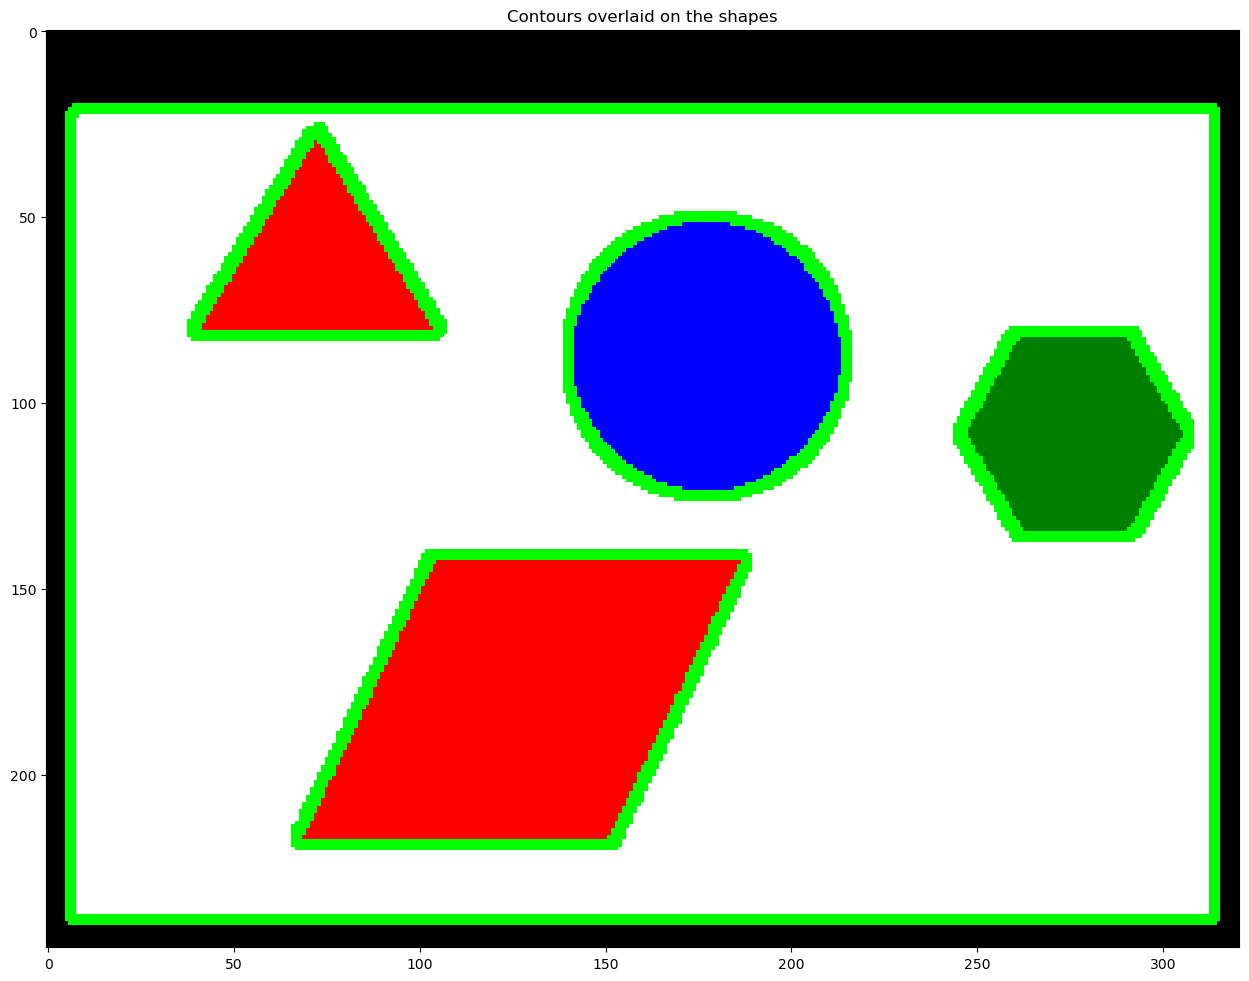

Contour areas before sorting...
Image: Shapes from net
[6704.0, 6744.5, 2565.5, 2627.5, 4443.0, 4503.0, 1944.5, 2011.0, 67140.5, 67141.0]
Contour areas after sorting...
Image: Shapes from net
[67141.0, 67140.5, 6744.5, 6704.0, 4503.0, 4443.0, 2627.5, 2565.5, 2011.0, 1944.5]


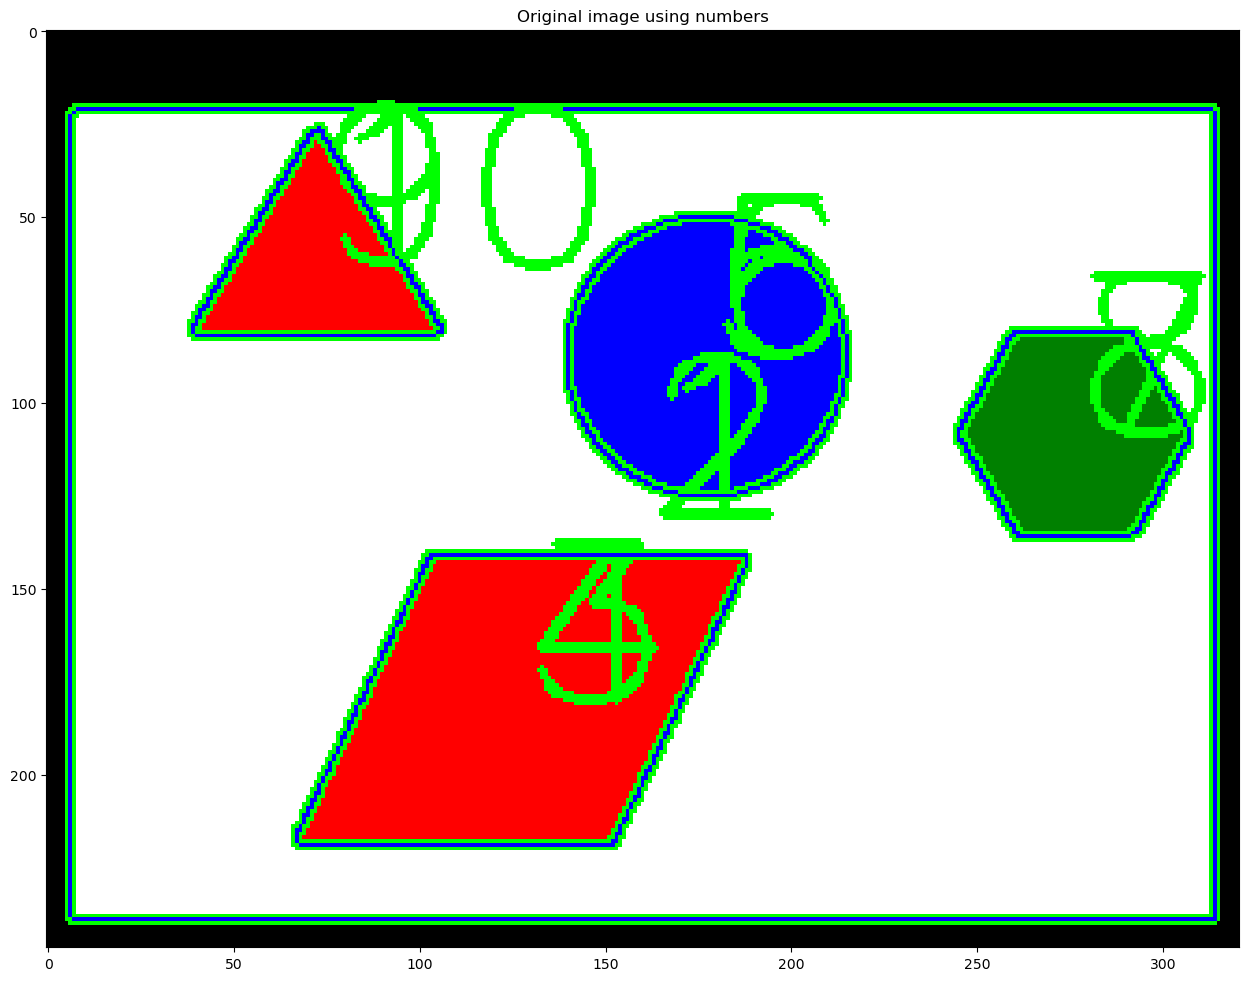

In [10]:
shapes2 = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/images_from_net2.png')
shapes2_grey = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/images_from_net2.png', 0)

edged = cv2.Canny(shapes2_grey, 50, 255)
imshow('Canny edged', edged, 20)

contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

cv2.drawContours(shapes2, contours, -1, (0, 255, 0), 2)
imshow('Contours overlaid on the shapes', shapes2, 20)

def get_contour_areas(title, contours):
    all_areas = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        all_areas.append(area)
    print('Image:',title)
    return all_areas


print('Contour areas before sorting...')
print(get_contour_areas('Shapes from net', contours))

sorted_contours = sorted(contours, key = cv2.contourArea, reverse=True)

print('Contour areas after sorting...')
print(get_contour_areas('Shapes from net', sorted_contours))

for (i,c) in enumerate(sorted_contours):
    M = cv2.moments(c)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    cv2.putText(shapes2, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 2)
    cv2.drawContours(shapes2, [c], -1, (255,0,0), 1)

imshow('Original image using numbers', shapes2, 20)

# **I will go back later to lose all bugs**


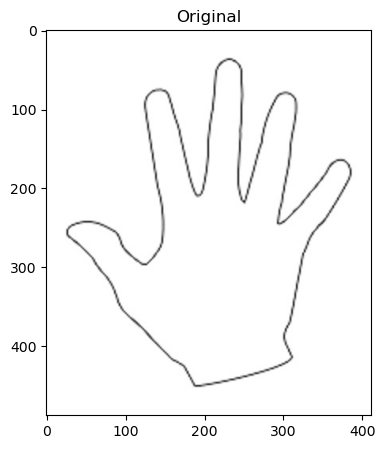

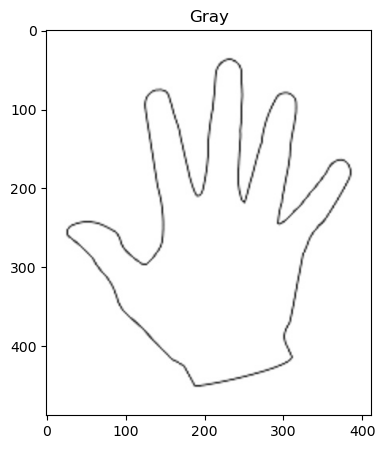

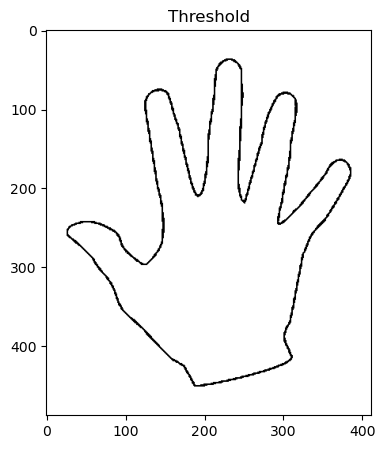

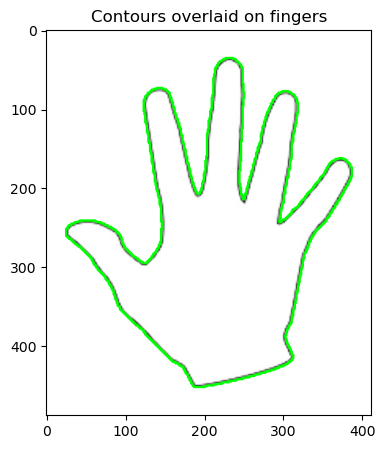

In [23]:
fingers = cv2.imread('/Users/apple/Desktop/Projects/Computer Vision/images/hand.jpg')
gray = cv2.cvtColor(fingers, cv2.COLOR_BGR2GRAY)
imshow('Original', fingers, 5)
imshow('Gray', gray, 5)

_ , th2 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('Threshold', th2, 5)

contours, hierarchy = cv2.findContours(th2.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(fingers, contours, 1, (0, 255, 0), 2 )

imshow('Contours overlaid on fingers', fingers, 5)